# Analyze Without-Priority Accumulated Results

This notebook analyzes `policy_results_without_priority_accumulated.csv` and finds Fair-policy patterns where mortality decreases as epsilon increases, per supply_rate and per experimental condition.

## ✅ Checklist
- [ ] Load and sanity-check the accumulated data
- [ ] Clean types (epsilon, supply_rate, mortality) and confirm policy categories
- [ ] Compute per-condition trends per supply_rate (epsilon → mortality) for Fair policy
- [ ] Summarize pattern stats (success rate by population, aged ratio, slope difference)
- [ ] Visualize distributions and example condition trends
- [ ] Save full results and decreasing-only subset

In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_rows', 100)
pd.set_option('display.max_columns', 100)
sns.set(style='whitegrid')

# Paths
BASE = Path(r'd:\python_workspace\mask_distribution\소스코드_10_23')
OUT = BASE / 'output'
ACC_FILE = OUT / 'policy_results_with_priority_accumulated.csv'

print('Data file:', ACC_FILE)
if not ACC_FILE.exists():
    raise FileNotFoundError(f'Not found: {ACC_FILE}')

df_all = pd.read_csv(ACC_FILE)
print('Loaded shape:', df_all.shape)
print('Columns:', list(df_all.columns))
print('Policies:', df_all['policy'].dropna().unique()[:10])
df_all.head(3)

Data file: d:\python_workspace\mask_distribution\소스코드_10_23\output\policy_results_with_priority_accumulated.csv
Loaded shape: (137126, 26)
Columns: ['Region1', 'Region2', 'Region1_NonAged', 'Region2_NonAged', 'Region1_Aged', 'Region2_Aged', 'Total_Mortality', 'R1_Aged_MaskRate', 'R1_NonAged_MaskRate', 'R2_Aged_MaskRate', 'R2_NonAged_MaskRate', 'policy', 'supply_rate', 'epsilon', 'aged_priority_ratio', 'Achieved_Utility', 'Total_Utility', 'Gini_Value', 'pop1', 'pop2', 'aged_ratio1', 'aged_ratio2', 'slope_na1', 'slope_a1', 'slope_na2', 'slope_a2']
Policies: ['Equal' 'Fair' 'Proportion' 'Utility']


,Region1,Region2,Region1_NonAged,Region2_NonAged,Region1_Aged,Region2_Aged,Total_Mortality,R1_Aged_MaskRate,R1_NonAged_MaskRate,R2_Aged_MaskRate,R2_NonAged_MaskRate,policy,supply_rate,epsilon,aged_priority_ratio,Achieved_Utility,Total_Utility,Gini_Value,pop1,pop2,aged_ratio1,aged_ratio2,slope_na1,slope_a1,slope_na2,slope_a2
0,0.085120,0.068625,0.046849,0.048724,0.238201,0.247732,0.073573,0.000000,0.0,0.000000,0.0,Equal,0.00,NaN,1.0,0.0,0.0,NaN,300000,700000,0.2,0.1,4,1,4,1
1,0.076482,0.065098,0.045652,0.048268,0.199803,0.216566,0.068513,0.416667,0.0,0.357143,0.0,Equal,0.05,NaN,1.0,200000.0,200000.0,0.095588,300000,700000,0.2,0.1,4,1,4,1
2,0.070916,0.062667,0.044828,0.047944,0.175268,0.195168,0.065141,0.833333,0.0,0.714286,0.0,Equal,0.10,NaN,1.0,400000.0,400000.0,0.095588,300000,700000,0.2,0.1,4,1,4,1


Data load check: If the file is missing, the cell raises an error. Verify columns like `policy`, `supply_rate`, `epsilon`, and `Total_Mortality` exist before proceeding to preprocessing.

In [2]:
# Preprocess: ensure types and Fair-only subset for trend analysis

df = df_all.copy()

# Coerce numeric
for col in ['epsilon', 'Total_Mortality', 'supply_rate', 'pop1', 'pop2', 'slope_na1', 'slope_a1', 'slope_na2', 'slope_a2']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

# Filter Fair policy only for trend analysis
if 'policy' in df.columns:
    df_fair = df[df['policy'] == 'Fair'].copy()
else:
    df_fair = df.copy()

# Drop rows without epsilon or mortality
before = len(df_fair)
df_fair.dropna(subset=['epsilon', 'Total_Mortality', 'supply_rate'], inplace=True)
after = len(df_fair)
print(f'Fair rows (after cleaning): {after} (dropped {before-after})')

# Note on slope columns naming:
# In the accumulated CSV, slope_naX actually stores aged slope, and slope_aX stores non-aged slope
# We'll compute slope differences accordingly (aged - non-aged)

df_fair['slope_diff_r1'] = df_fair['slope_na1'] - df_fair['slope_a1']
df_fair['slope_diff_r2'] = df_fair['slope_na2'] - df_fair['slope_a2']
df_fair['pop_ratio'] = df_fair.apply(lambda r: f"{int(r['pop1']/10000)}:{int(r['pop2']/10000)}", axis=1)

df_fair.head(3)

Fair rows (after cleaning): 119240 (dropped 0)


,Region1,Region2,Region1_NonAged,Region2_NonAged,Region1_Aged,Region2_Aged,Total_Mortality,R1_Aged_MaskRate,R1_NonAged_MaskRate,R2_Aged_MaskRate,R2_NonAged_MaskRate,policy,supply_rate,epsilon,aged_priority_ratio,Achieved_Utility,Total_Utility,Gini_Value,pop1,pop2,aged_ratio1,aged_ratio2,slope_na1,slope_a1,slope_na2,slope_a2,slope_diff_r1,slope_diff_r2,pop_ratio
11,0.08512,0.068625,0.046849,0.048724,0.238201,0.247732,0.073573,0.0,0.0,0.0,0.0,Fair,0.0,0.02,1.0,0.0,0.0,NaN,300000,700000,0.2,0.1,4,1,4,1,3,3,30:70
12,0.08512,0.068625,0.046849,0.048724,0.238201,0.247732,0.073573,0.0,0.0,0.0,0.0,Fair,0.0,0.05,1.0,0.0,0.0,NaN,300000,700000,0.2,0.1,4,1,4,1,3,3,30:70
13,0.08512,0.068625,0.046849,0.048724,0.238201,0.247732,0.073573,0.0,0.0,0.0,0.0,Fair,0.0,0.08,1.0,0.0,0.0,NaN,300000,700000,0.2,0.1,4,1,4,1,3,3,30:70


Preprocessing check: Confirm the `Fair` subset count is reasonable and that epsilon/Total_Mortality are numeric. If counts look off, inspect `policy` values to ensure Fair exists in this file.

## Compute per-condition trends (per supply_rate)

We'll compute a linear trend of Total_Mortality versus epsilon for each unique condition (including supply_rate), then summarize decreasing patterns.

In [3]:
# Build condition keys dynamically and compute epsilon->mortality trends per supply_rate
import os
import numpy as np
import pandas as pd

assert 'df' in globals(), "DataFrame 'df' not found. Run the loading cell first."
assert 'df_fair' in globals(), "DataFrame 'df_fair' not found. Run the preprocessing cell first."

work_df = df_fair.copy()

# Standardize column names (lowercase) for robust matching
work_df.columns = [c.strip() for c in work_df.columns]

# Required numeric columns
num_cols = []
for col in ['epsilon', 'Total_Mortality', 'total_mortality']:
    if col in work_df.columns:
        work_df[col] = pd.to_numeric(work_df[col], errors='coerce')
        num_cols.append(col)

# Prefer 'Total_Mortality' canonical name
if 'Total_Mortality' not in work_df.columns and 'total_mortality' in work_df.columns:
    work_df['Total_Mortality'] = work_df['total_mortality']

# Collect slope and ratio columns if present
slope_cols = [c for c in work_df.columns if c.lower().startswith('slope_')]
aged_ratio_cols = [c for c in work_df.columns if 'aged' in c.lower() and 'ratio' in c.lower()]

# Use pop_ratio created in preprocessing if available
condition_keys = []
if 'pop_ratio' in work_df.columns:
    condition_keys.append('pop_ratio')

# Include slope columns explicitly to uniquely identify conditions
# Expecting columns like slope_na1, slope_na2, slope_a1, slope_a2; include any available
condition_keys.extend(sorted(slope_cols))

# Include aged ratio columns if present
condition_keys.extend(sorted(aged_ratio_cols))

# Always include supply_rate as part of the condition
if 'supply_rate' in work_df.columns:
    condition_keys.append('supply_rate')
else:
    raise ValueError("Column 'supply_rate' not found; expected for per-rate analysis.")

# Remove keys that might be duplicated or non-existent (safety)
condition_keys = [k for k in condition_keys if k in work_df.columns]

# Compute the set of unique condition groups ignoring epsilon
unique_conditions = work_df[condition_keys].drop_duplicates()

def compute_trend(group: pd.DataFrame):
    # Guard: need at least 2 distinct epsilon values
    eps = group['epsilon'].dropna().values if 'epsilon' in group.columns else None
    mort = group['Total_Mortality'].dropna().values if 'Total_Mortality' in group.columns else None
    if eps is None or mort is None:
        return pd.Series({
            'n_rows': len(group),
            'n_eps': 0,
            'slope': np.nan,
            'intercept': np.nan,
            'r': np.nan,
            'r2': np.nan,
            'is_decreasing': np.nan,
        })
    # Align paired arrays (after dropna on both)
    tmp = pd.DataFrame({'epsilon': group['epsilon'], 'Total_Mortality': group['Total_Mortality']}).dropna()
    eps = tmp['epsilon'].values
    mort = tmp['Total_Mortality'].values
    if len(np.unique(eps)) < 2:
        return pd.Series({
            'n_rows': len(group),
            'n_eps': len(np.unique(eps)),
            'slope': np.nan,
            'intercept': np.nan,
            'r': np.nan,
            'r2': np.nan,
            'is_decreasing': np.nan,
        })
    try:
        slope, intercept = np.polyfit(eps, mort, 1)
        # Pearson correlation
        r = np.corrcoef(eps, mort)[0, 1]
        r2 = r ** 2 if np.isfinite(r) else np.nan
        return pd.Series({
            'n_rows': len(group),
            'n_eps': len(np.unique(eps)),
            'slope': float(slope),
            'intercept': float(intercept),
            'r': float(r),
            'r2': float(r2),
            'is_decreasing': bool(slope < 0),
        })
    except Exception:
        return pd.Series({
            'n_rows': len(group),
            'n_eps': len(np.unique(eps)),
            'slope': np.nan,
            'intercept': np.nan,
            'r': np.nan,
            'r2': np.nan,
            'is_decreasing': np.nan,
        })

# Group and compute
trend_results = work_df.groupby(condition_keys, dropna=False).apply(compute_trend).reset_index()

# Meta counts
total_conditions = len(unique_conditions)
# analyzed conditions have at least 2 epsilon values
analyzed_conditions = int((trend_results['n_eps'] >= 2).sum())
skipped_conditions = total_conditions - analyzed_conditions

print(f"Condition keys: {condition_keys}")
print(f"Total unique conditions (per supply_rate): {total_conditions}")
print(f"Analyzed (>=2 epsilons): {analyzed_conditions}")
print(f"Skipped: {skipped_conditions}")

# Decreasing summary
if 'is_decreasing' in trend_results.columns:
    valid_mask = trend_results['is_decreasing'].isin([True, False])
    n_valid = int(valid_mask.sum())
    n_decreasing = int(trend_results.loc[valid_mask, 'is_decreasing'].sum())
    pct_decreasing = (n_decreasing / n_valid * 100) if n_valid > 0 else np.nan
    print(f"Valid trend groups: {n_valid}; Decreasing: {n_decreasing} ({pct_decreasing:.1f}%)")

# Create slope-diff features if model slope columns exist
if set(['slope_na1','slope_a1']).issubset(work_df.columns):
    trend_results['slope_diff_1'] = trend_results['slope_na1'] - trend_results['slope_a1']
if set(['slope_na2','slope_a2']).issubset(work_df.columns):
    trend_results['slope_diff_2'] = trend_results['slope_na2'] - trend_results['slope_a2']
if {'slope_diff_1','slope_diff_2'}.issubset(trend_results.columns):
    trend_results['slope_diff_pair'] = trend_results['slope_diff_1'].astype('Int64').astype(str) + '|' + trend_results['slope_diff_2'].astype('Int64').astype(str)

# Preview
trend_results.head()

C:\Users\ch2pa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ch2pa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\ch2pa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2853: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
C:\Users\ch2pa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\numpy\lib\function_base.py:2854: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
C:\Users\ch2

Condition keys: ['pop_ratio', 'slope_a1', 'slope_a2', 'slope_diff_r1', 'slope_diff_r2', 'slope_na1', 'slope_na2', 'aged_priority_ratio', 'aged_ratio1', 'aged_ratio2', 'supply_rate']
Total unique conditions (per supply_rate): 5940
Analyzed (>=2 epsilons): 5940
Skipped: 0
Valid trend groups: 5940; Decreasing: 3082 (51.9%)


,pop_ratio,slope_a1,slope_a2,slope_diff_r1,slope_diff_r2,slope_na1,slope_na2,aged_priority_ratio,aged_ratio1,aged_ratio2,supply_rate,n_rows,n_eps,slope,intercept,r,r2,is_decreasing,slope_diff_1,slope_diff_2,slope_diff_pair
0,30:70,1,1,0,0,1,1,1.0,0.2,0.1,0.00,20,20,-1.030101e-16,0.073573,1.911634e-17,3.654343e-34,True,0,0,0|0
1,30:70,1,1,0,0,1,1,1.0,0.2,0.1,0.05,20,20,1.745207e-03,0.068299,9.195933e-01,8.456518e-01,False,0,0,0|0
2,30:70,1,1,0,0,1,1,1.0,0.2,0.1,0.10,20,20,1.706525e-03,0.064934,8.804156e-01,7.751316e-01,False,0,0,0|0
3,30:70,1,1,0,0,1,1,1.0,0.2,0.1,0.15,20,20,-1.432076e-03,0.062354,-8.675998e-01,7.527294e-01,True,0,0,0|0
4,30:70,1,1,0,0,1,1,1.0,0.2,0.1,0.20,20,20,-8.937479e-04,0.059288,-7.816457e-01,6.109700e-01,True,0,0,0|0


### Validation
- Total unique conditions should equal unique combinations of the displayed condition keys (including supply_rate).
- Analyzed count excludes groups with fewer than 2 epsilon values.
- Decreasing means the fitted slope of Total_Mortality vs epsilon is negative.

In [4]:
# Summaries: decreasing shares by pop_ratio and slope_diff_pair (if present)
import pandas as pd

assert 'trend_results' in globals(), "Run the trend computation cell first."

summary_outputs = {}

if 'pop_ratio' in trend_results.columns and 'is_decreasing' in trend_results.columns:
    dec_by_pop = (trend_results
        .dropna(subset=['is_decreasing'])
        .groupby('pop_ratio')['is_decreasing']
        .agg(['count', 'sum'])
        .rename(columns={'sum': 'decreasing'})
        .assign(share=lambda d: (d['decreasing'] / d['count'] * 100).round(1))
        .reset_index())
    summary_outputs['dec_by_pop_ratio'] = dec_by_pop
    display(dec_by_pop.head())

if 'slope_diff_pair' in trend_results.columns and 'is_decreasing' in trend_results.columns:
    dec_by_sdiff = (trend_results
        .dropna(subset=['is_decreasing'])
        .groupby('slope_diff_pair')['is_decreasing']
        .agg(['count', 'sum'])
        .rename(columns={'sum': 'decreasing'})
        .assign(share=lambda d: (d['decreasing'] / d['count'] * 100).round(1))
        .reset_index()
        .sort_values(['share','count'], ascending=[False, False]))
    summary_outputs['dec_by_slope_diff_pair'] = dec_by_sdiff
    display(dec_by_sdiff.head(10))

# Joint summary if both available
if {'pop_ratio','slope_diff_pair'}.issubset(trend_results.columns):
    dec_by_both = (trend_results
        .dropna(subset=['is_decreasing'])
        .groupby(['pop_ratio','slope_diff_pair'])['is_decreasing']
        .agg(['count','sum'])
        .rename(columns={'sum':'decreasing'})
        .assign(share=lambda d: (d['decreasing']/d['count']*100).round(1))
        .reset_index()
        .sort_values(['share','count'], ascending=[False, False]))
    summary_outputs['dec_by_pop_ratio_and_slope_diff_pair'] = dec_by_both
    display(dec_by_both.head(10))

print("Summaries computed:", list(summary_outputs.keys()))

,pop_ratio,count,decreasing,share
0,30:70,1188,504,42.4
1,40:60,1188,540,45.5
2,50:50,1188,569,47.9
3,60:40,1188,720,60.6
4,70:30,1188,749,63.0


,slope_diff_pair,count,decreasing,share
6,1|2,660,344,52.1
9,2|1,660,344,52.1
10,2|2,660,344,52.1
1,0|1,330,172,52.1
2,0|2,330,172,52.1
4,1|0,330,172,52.1
7,1|3,330,172,52.1
8,2|0,330,172,52.1
11,2|3,330,172,52.1
13,3|1,330,172,52.1


,pop_ratio,slope_diff_pair,count,decreasing,share
70,70:30,1|2,132,84,63.6
73,70:30,2|1,132,84,63.6
74,70:30,2|2,132,84,63.6
65,70:30,0|1,66,42,63.6
66,70:30,0|2,66,42,63.6
68,70:30,1|0,66,42,63.6
71,70:30,1|3,66,42,63.6
72,70:30,2|0,66,42,63.6
75,70:30,2|3,66,42,63.6
77,70:30,3|1,66,42,63.6


Summaries computed: ['dec_by_pop_ratio', 'dec_by_slope_diff_pair', 'dec_by_pop_ratio_and_slope_diff_pair']


### Example visualization
Pick one condition (most decreasing) and plot epsilon vs Total_Mortality with a fitted line to validate the trend intuitively.

Selected condition:


pop_ratio                 70:30
slope_a1                      2
slope_a2                      1
slope_diff_r1                 1
slope_diff_r2                 2
slope_na1                     3
slope_na2                     3
aged_priority_ratio         1.0
aged_ratio1                 0.5
aged_ratio2                 0.3
supply_rate                0.15
n_rows                       20
n_eps                        20
slope                 -0.006587
intercept              0.097442
r                     -0.931749
r2                     0.868157
is_decreasing              True
slope_diff_1                  1
slope_diff_2                  2
slope_diff_pair             1|2
Name: 5635, dtype: object

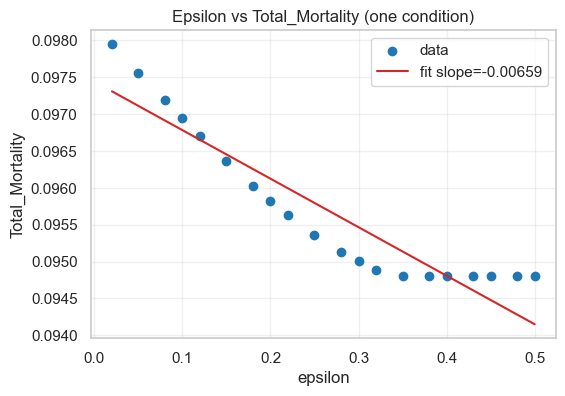

In [5]:
# Visualization: plot one selected condition's epsilon vs Total_Mortality
import matplotlib.pyplot as plt
import numpy as np

assert 'work_df' in globals() and 'trend_results' in globals()

# Choose a strongly decreasing condition (most negative slope)
if 'slope' in trend_results.columns and len(trend_results.dropna(subset=['slope'])):
    cand = trend_results.dropna(subset=['slope']).sort_values('slope').iloc[0]
    print("Selected condition:")
    display(cand)

    # Build a mask to filter the original rows for this condition
    mask = pd.Series(True, index=work_df.index)
    for key in [k for k in trend_results.columns if k in work_df.columns and k in cand.index]:
        mask &= (work_df[key] == cand[key])

    sub = work_df.loc[mask, ['epsilon', 'Total_Mortality']].dropna()
    sub = sub.sort_values('epsilon')

    plt.figure(figsize=(6,4))
    plt.scatter(sub['epsilon'], sub['Total_Mortality'], color='tab:blue', label='data')
    if len(sub) >= 2:
        m, b = np.polyfit(sub['epsilon'], sub['Total_Mortality'], 1)
        xs = np.linspace(sub['epsilon'].min(), sub['epsilon'].max(), 50)
        plt.plot(xs, m*xs + b, color='tab:red', label=f'fit slope={m:.3g}')
    plt.title('Epsilon vs Total_Mortality (one condition)')
    plt.xlabel('epsilon')
    plt.ylabel('Total_Mortality')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
else:
    print("No valid slope results to visualize.")

### Save outputs
We'll save the full trend results and the decreasing-only subset into the `output/` folder next to the accumulated CSV.

In [7]:
# Save trend results and decreasing-only subset
from pathlib import Path

assert 'trend_results' in globals(), "Run the trend computation cell first."

# Derive output directory from the loaded CSV path if available; else default to './output'
if 'path' in globals() and isinstance(path, (str, Path)):
    p = Path(path)
    out_dir = p.parent
else:
    out_dir = Path.cwd() / 'output'

out_dir.mkdir(parents=True, exist_ok=True)

full_out = out_dir / 'with_priority_trend_results.csv'
dec_out = out_dir / 'with_priority_trend_results_decreasing.csv'

trend_results.to_csv(full_out, index=False)
trend_results[trend_results['is_decreasing'] == True].to_csv(dec_out, index=False)

print(f"Saved full trends -> {full_out}")
print(f"Saved decreasing-only -> {dec_out}")

Saved full trends -> d:\python_workspace\mask_distribution\소스코드_10_23\output\with_priority_trend_results.csv
Saved decreasing-only -> d:\python_workspace\mask_distribution\소스코드_10_23\output\with_priority_trend_results_decreasing.csv
